# 23i-2532 | Data Analysis and Visualization | Lab 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

vibrant = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A4C93', '#1A936F', '#FF9F1C', '#F72585', '#4361EE']

df = sns.load_dataset('tips')
df.head()


## Task 1: Bar Chart — Compare a Category

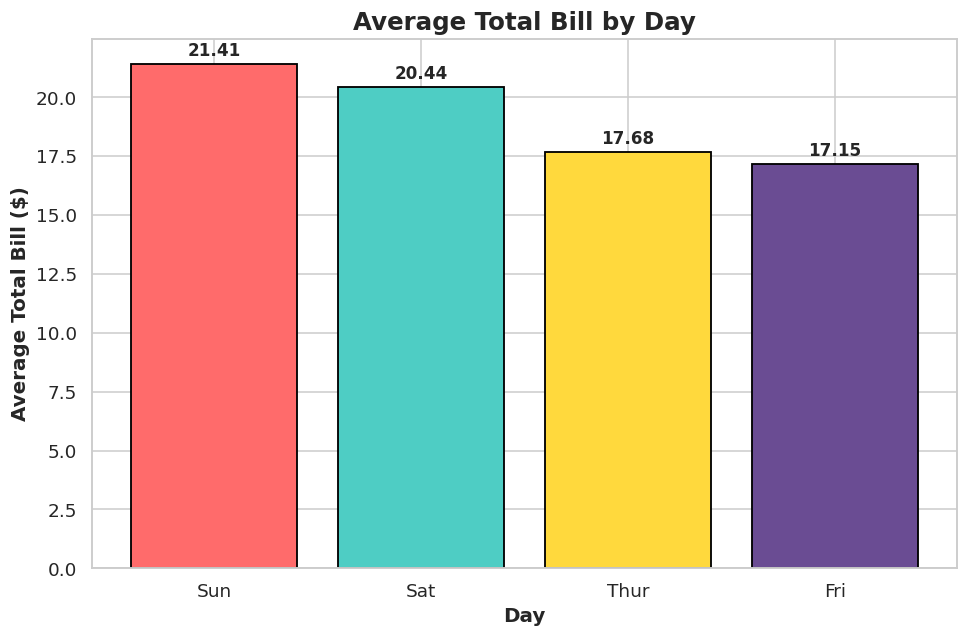

In [2]:
avg_bill_by_day = df.groupby('day', observed=True)['total_bill'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(avg_bill_by_day.index.astype(str), avg_bill_by_day.values, color=vibrant, edgecolor='black', linewidth=1.2)
ax.bar_label(bars, fmt='%.2f', fontsize=11, fontweight='bold', padding=3)
ax.set_xlabel('Day', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Total Bill ($)', fontsize=13, fontweight='bold')
ax.set_title('Average Total Bill by Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Task 2: Count Plot — Category Frequency

Most common category: Sat (87 records)


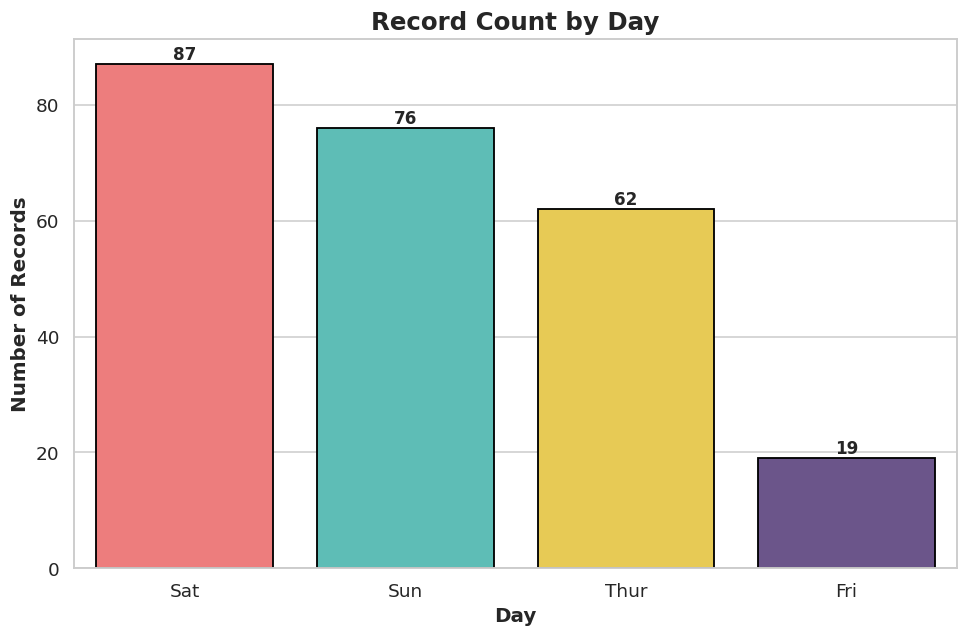

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
order = df['day'].value_counts().index
sns.countplot(x='day', data=df, order=order, palette=vibrant, edgecolor='black', linewidth=1.2, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Day', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Records', fontsize=13, fontweight='bold')
ax.set_title('Record Count by Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Most common category: {df['day'].value_counts().idxmax()} ({df['day'].value_counts().max()} records)")


## Task 3: Histogram — Distribution Shape

Skewness: 1.133 -> the distribution is right-skewed (a long tail toward higher bill amounts).


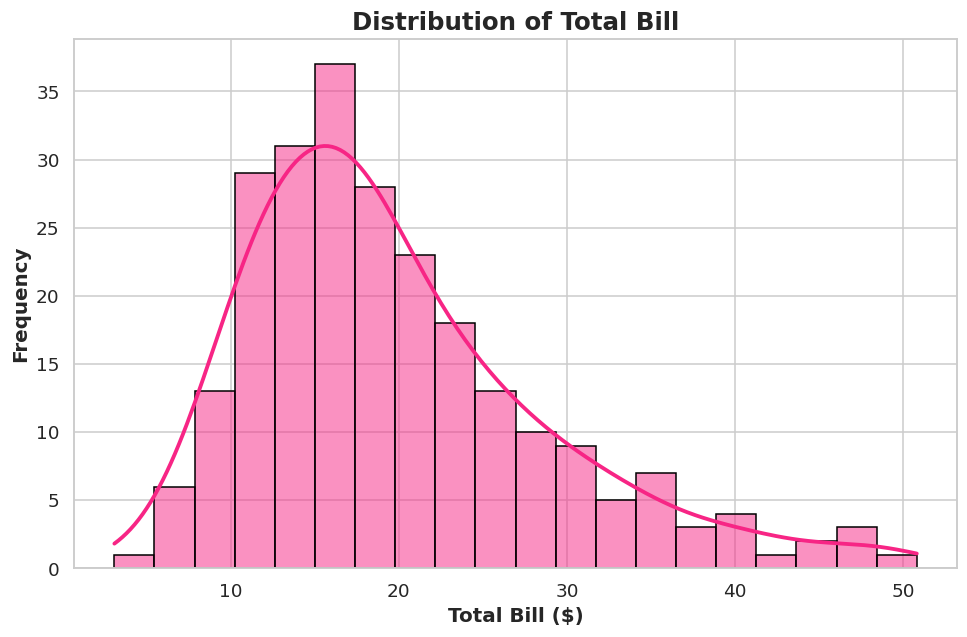

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df['total_bill'], bins=20, color='#F72585', edgecolor='black', kde=True, ax=ax, line_kws={'color': '#4361EE', 'linewidth': 2.5})
ax.set_xlabel('Total Bill ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Total Bill', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

skewness = df['total_bill'].skew()
print(f"Skewness: {skewness:.3f} -> the distribution is right-skewed (a long tail toward higher bill amounts).")


## Task 4: Box Plot — Visual Outlier Detection

Outlier points visible beyond the whiskers: 9


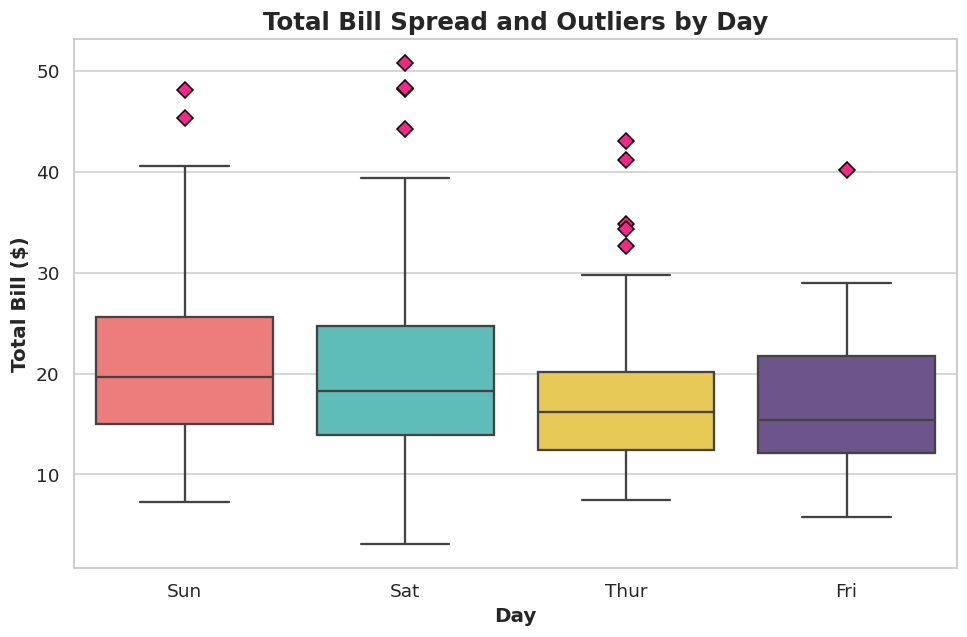

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(x='day', y='total_bill', data=df, palette=vibrant, ax=ax, linewidth=1.5, fliersize=7,
            flierprops=dict(marker='D', markerfacecolor='#F72585', markeredgecolor='black'))
ax.set_xlabel('Day', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Bill ($)', fontsize=13, fontweight='bold')
ax.set_title('Total Bill Spread and Outliers by Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
visual_outliers = df[(df['total_bill'] < lower) | (df['total_bill'] > upper)]
print(f"Outlier points visible beyond the whiskers: {len(visual_outliers)}")


## Task 5: Outlier Detection — The Mechanism (IQR)

In [6]:
col = 'total_bill'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(len(outliers))
print(f"IQR count matches the visual count from Task 4: {len(outliers) == len(visual_outliers)}")


9
IQR count matches the visual count from Task 4: True


## Task 6: Outlier Detection — Z-score Comparison

In [7]:
df['zscore'] = stats.zscore(df['total_bill'])
outliers_z = df[df['zscore'].abs() > 3]
print(len(outliers_z))

print(f"IQR flagged {len(outliers)} outliers, Z-score flagged {len(outliers_z)}.")
print("They differ because total_bill is right-skewed rather than normally distributed: IQR is based on quartiles and stays robust under skew, while Z-score relies on the mean and standard deviation, which get pulled toward the long right tail, making the 3-sigma threshold less sensitive to the same high values.")


4
IQR flagged 9 outliers, Z-score flagged 4.
They differ because total_bill is right-skewed rather than normally distributed: IQR is based on quartiles and stays robust under skew, while Z-score relies on the mean and standard deviation, which get pulled toward the long right tail, making the 3-sigma threshold less sensitive to the same high values.


## Task 7: Scatter Plot — Relationship Between Two Variables

Correlation: 0.676 -> a positive relationship: tip tends to increase as total bill increases.


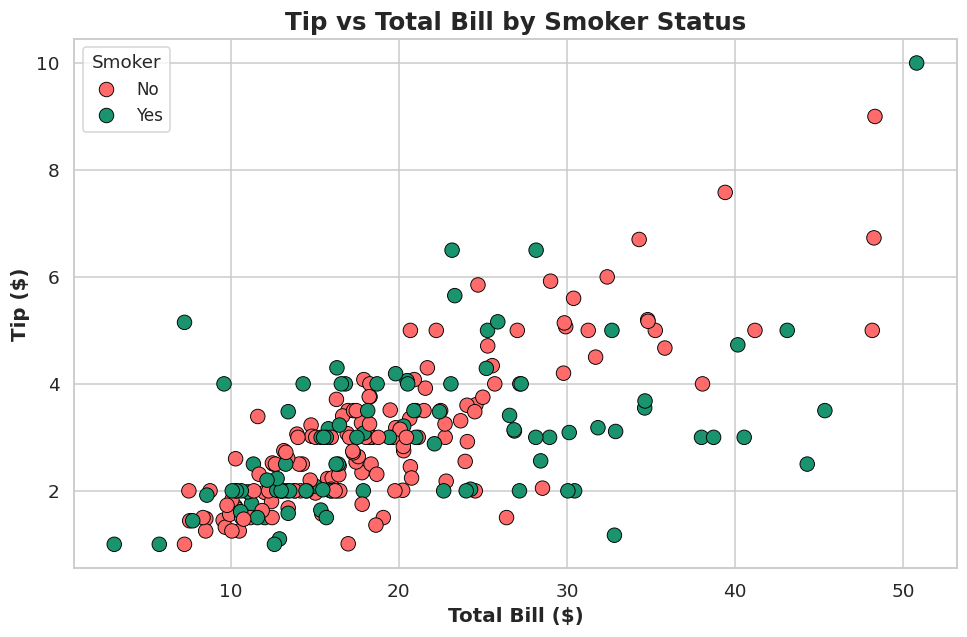

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(x='total_bill', y='tip', hue='smoker', data=df, palette=['#FF6B6B', '#1A936F'], s=90, edgecolor='black', linewidth=0.6, ax=ax)
ax.set_xlabel('Total Bill ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tip ($)', fontsize=13, fontweight='bold')
ax.set_title('Tip vs Total Bill by Smoker Status', fontsize=16, fontweight='bold')
ax.legend(title='Smoker', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

corr = df['total_bill'].corr(df['tip'])
print(f"Correlation: {corr:.3f} -> a positive relationship: tip tends to increase as total bill increases.")


## Task 8: Line/Area Chart — Trend Across an Ordered Variable

The line chart shows only the direction and rate of change between days, while the area chart's shaded fill draws extra attention to the overall magnitude, making the total volume of tips feel more prominent even though the underlying values are identical.


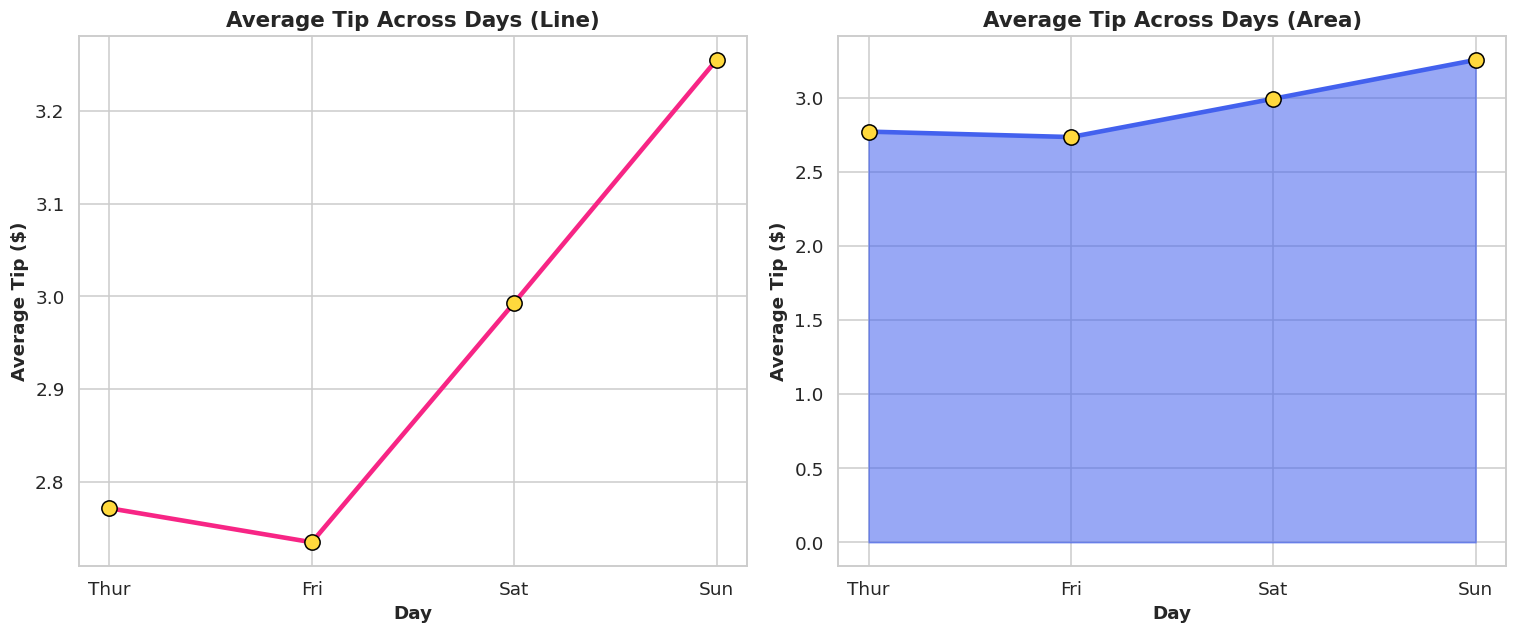

In [9]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_tip_by_day = df.groupby('day', observed=True)['tip'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(avg_tip_by_day.index, avg_tip_by_day.values, color='#F72585', marker='o', markersize=10, linewidth=3, markerfacecolor='#FFD93D', markeredgecolor='black')
axes[0].set_title('Average Tip Across Days (Line)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Tip ($)', fontsize=12, fontweight='bold')

axes[1].fill_between(avg_tip_by_day.index, avg_tip_by_day.values, color='#4361EE', alpha=0.55)
axes[1].plot(avg_tip_by_day.index, avg_tip_by_day.values, color='#4361EE', marker='o', markersize=10, linewidth=3, markerfacecolor='#FFD93D', markeredgecolor='black')
axes[1].set_title('Average Tip Across Days (Area)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Tip ($)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("The line chart shows only the direction and rate of change between days, while the area chart's shaded fill draws extra attention to the overall magnitude, making the total volume of tips feel more prominent even though the underlying values are identical.")


## Task 9: Graphical Integrity Check

Even though the counts themselves never change, truncating the y-axis in the second chart stretches out the small differences between days, making Saturday and Sunday look dramatically busier than Thursday or Friday. The first, zero-based chart makes the true proportional difference between days clear, while the truncated version visually exaggerates a gap that is actually fairly modest.


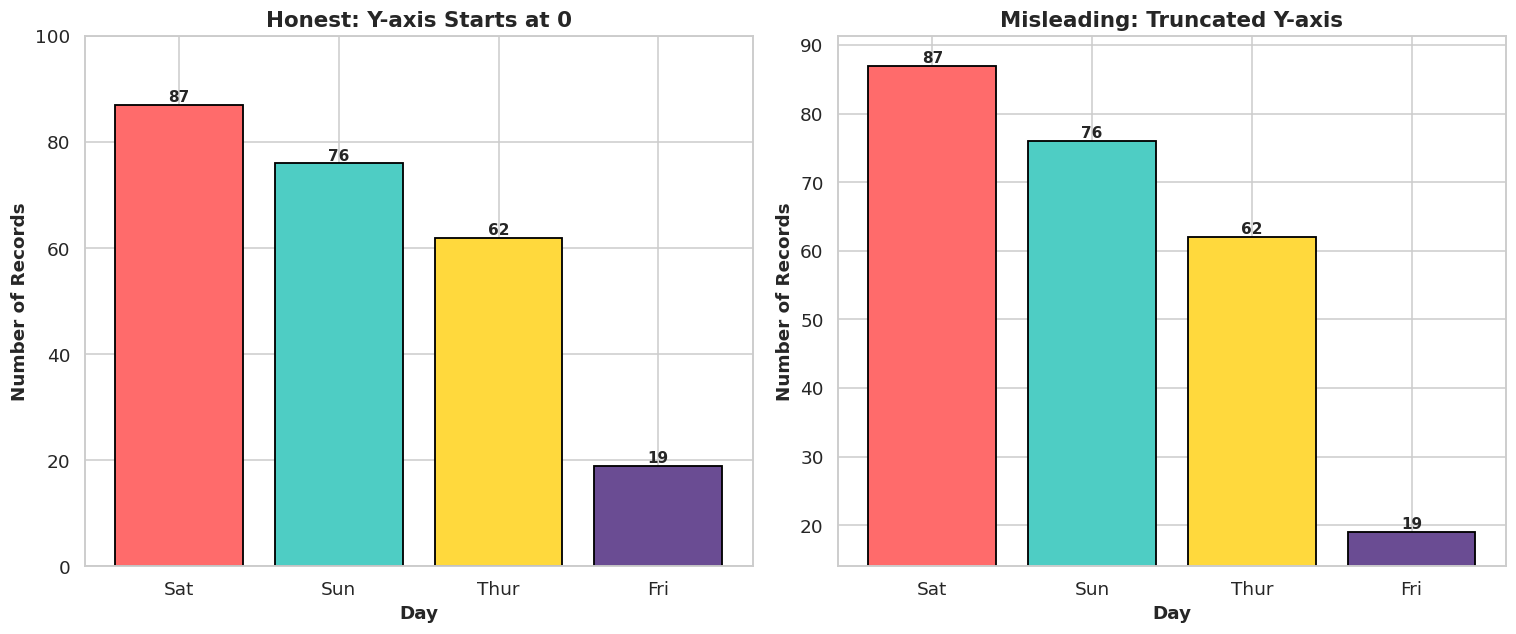

In [10]:
counts = df['day'].value_counts().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars0 = axes[0].bar(counts.index.astype(str), counts.values, color=vibrant, edgecolor='black', linewidth=1.2)
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].set_title('Honest: Y-axis Starts at 0', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
axes[0].bar_label(bars0, fontsize=10, fontweight='bold')

bars1 = axes[1].bar(counts.index.astype(str), counts.values, color=vibrant, edgecolor='black', linewidth=1.2)
axes[1].set_ylim(bottom=counts.min() - 5)
axes[1].set_title('Misleading: Truncated Y-axis', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
axes[1].bar_label(bars1, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Even though the counts themselves never change, truncating the y-axis in the second chart stretches out the small differences between days, making Saturday and Sunday look dramatically busier than Thursday or Friday. The first, zero-based chart makes the true proportional difference between days clear, while the truncated version visually exaggerates a gap that is actually fairly modest.")
